# Contexte
Une entreprise dispose de données provenant de plusieurs bâtiments équipés de capteurs.
Pour chaque observation, on dispose par exemple de la température moyenne, de l’humidité, du
nombre d'occupants, de l’heure, du jour de la semaine, de la surface du bâtiment et de la
consommation énergétique.
L'objectif de l’atelier est de construire avec TensorFlow/Keras un réseau de neurones capable de
prédire la consommation énergétique d'un bâtiment à partir de caractéristiques telles que
température, humidité et nombre d'occupants.

In [1]:
! pip install numpy matplotlib scikit-learn tensorflow

  Using cached numpy-2.5.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (80 kB)
  Using cached scikit_learn-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1

In [2]:
# Import des bibliothèques nécessaires
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

I0000 00:00:1787446139.884219    5429 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787446139.966063    5429 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787446142.725300    5429 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# Partie 1 – Génération du dataset

## 1) Générer aléatoirement 1000 valeurs pour chacune des variables suivantes :
a) temperature : valeurs qui suivent une loi normale avec une moyenne de 25 °C et un
écart-type de 4 °C.

b) humidite : valeurs réparties de façon uniforme entre 30 % et 80 %.

c) occupants : valeurs entières choisies entre 1 et 49 inclus.


In [3]:
np.random.seed(42)

N = 1000

# a) température : loi normale (moyenne 25°C, écart-type 4°C)
temperature = np.random.normal(loc=25, scale=4, size=N)

# b) humidité : loi uniforme entre 30% et 80%
humidite = np.random.uniform(low=30, high=80, size=N)

# c) occupants : entiers entre 1 et 49 inclus
occupants = np.random.randint(low=1, high=50, size=N)  # high exclusif -> 1 à 49 inclus

print("temperature :", temperature[:5])
print("humidite    :", humidite[:5])
print("occupants   :", occupants[:5])

temperature : [26.98685661 24.4469428  27.59075415 31.09211943 24.0633865 ]
humidite    : [38.37412911 35.22839202 61.82151248 65.32378632 31.57930724]
occupants   : [ 8 43 20 33 26]


## 2) Déterminer la variable consommation avec la formule suivante :

* la consommation de base (0 °C, pas d'humidité et pièce vide) est de 50
* chaque degré supplémentaire augmente la consommation de 5 unités
* chaque pourcentage d'humidité en plus ajoute 1,5 unité à la consommation
* chaque personne présente dans la pièce augmente la consommation de 4 unités 
* dans la vraie vie, une formule mathématique parfaite n'existe pas. On ajoute donc une petite variation aléatoire (moyenne de 0 et écart-type de 10) pour simuler des imprévus ou d'autres facteurs non mesurés.

In [4]:
bruit = np.random.normal(loc=0, scale=10, size=N)

consommation = (
    50
    + 5 * temperature
    + 1.5 * humidite
    + 4 * occupants
    + bruit
)

print("consommation (aperçu) :", consommation[:5])
print("consommation moyenne  :", consommation.mean().round(2))

consommation (aperçu) : [281.62608854 406.67868707 348.62841819 433.63621523 318.9414931 ]
consommation moyenne  : 361.64


## 3) Rassembler les variables (temperature, humidite et occupants) dans la matrice des caractéristiques (features) X de taille 1000x3 en convertissant éventuellement les données au format (float32) optimisé pour les calculs

In [5]:
# Construction de la matrice des features X (1000 x 3) et de la cible y
X = np.column_stack([temperature, humidite, occupants]).astype(np.float32)
print("Forme de X :", X.shape)
print("X[:3] =\n", X[:3])

Forme de X : (1000, 3)
X[:3] =
 [[26.986856 38.37413   8.      ]
 [24.446943 35.228394 43.      ]
 [27.590754 61.821514 20.      ]]


## 4) Créer la cible (target) y qui contiendra la variable consommation, au format float32

In [6]:
# Construction de la matrice des features X (1000 x 3) et de la cible y
y = consommation.astype(np.float32)

print("Forme de y :", y.shape)
print("y[:3] =", y[:3])

Forme de y : (1000,)
y[:3] = [281.6261  406.67868 348.62842]


# Partie 2 – Découpage Train/Test
Diviser le dataset précédent (X et y) en deux ensembles distincts : un pour l'entraînement (train)
et un pour le test (test). Avec les conditions suivantes : 20% des données serviront au test ; garantir
la reproductibilité du découpage.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train :", X_train.shape, "| X_test :", X_test.shape)
print("y_train :", y_train.shape, "| y_test :", y_test.shape)

X_train : (800, 3) | X_test : (200, 3)
y_train : (800,) | y_test : (200,)


## Partie 3 — Création du modèle

## 1) Construire un réseau de neurones qui utilise l’architecture séquentielle suivante :



- Couche 1 : 16 neurones, activation ReLU
- Couche 2 : 8 neurones, activation ReLU
- Couche 3 : 1 neurone (sortie, régression)

In [8]:
model = keras.Sequential([
    layers.Input(shape=(3,)),
    layers.Dense(16, activation="relu", name="couche_1"),
    layers.Dense(8, activation="relu", name="couche_2"),
    layers.Dense(1, name="couche_sortie"),
])


E0000 00:00:1787446206.294567    5429 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2) Afficher un résumé textuel de l'architecture du réseau de neurones.

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ couche_1 (Dense)                │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ couche_2 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ couche_sortie (Dense)           │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

# Partie 4 – Compilation du modèle
Compiler le modèle avec une méthode pour ajuster les poids, une fonction permettant de mesurer
l'erreur de prédiction et une métrique permettant de suivre l'erreur absolue moyenne.

In [10]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"],
)

# Partie 5 — Entraînement du modèle

## 1) Entrainer le modèle avec 20 % des données d'entraînement utilisés pour la validation, 50 passages sur les données et 16 observations traitées à la fois. Sauvegarder, dans la variable history, l'historique de l’entraînement

In [13]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=0,
)

print("Entraînement terminé.")

Entraînement terminé.


## 2) Examiner le contenu de history

In [14]:
# Contenu de l'historique
print("Clés disponibles dans history.history :", list(history.history.keys()))
print("Loss (train) - 5 dernières valeurs :", np.round(history.history["loss"][-5:], 2))
print("MAE (train)  - 5 dernières valeurs :", np.round(history.history["mae"][-5:], 2))
print("Loss (val)   - 5 dernières valeurs :", np.round(history.history["val_loss"][-5:], 2))
print("MAE (val)    - 5 dernières valeurs :", np.round(history.history["val_mae"][-5:], 2))

Clés disponibles dans history.history : ['loss', 'mae', 'val_loss', 'val_mae']
Loss (train) - 5 dernières valeurs : [152.05 150.05 150.17 150.45 148.39]
MAE (train)  - 5 dernières valeurs : [9.91 9.85 9.85 9.84 9.84]
Loss (val)   - 5 dernières valeurs : [140.18 137.05 136.3  135.81 135.11]
MAE (val)    - 5 dernières valeurs : [9.6  9.46 9.43 9.42 9.39]


## 3) Se servir de l’historique pour visualiser (graphique) et interpréter l’apprentissage

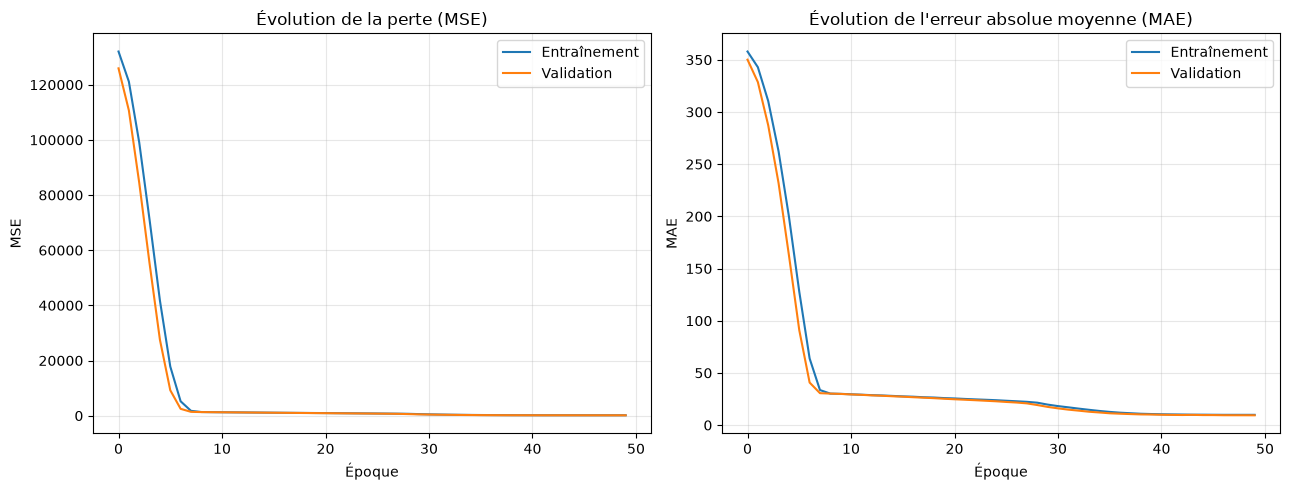

In [15]:
# Visualisation de l'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history.history["loss"], label="Entraînement")
axes[0].plot(history.history["val_loss"], label="Validation")
axes[0].set_title("Évolution de la perte (MSE)")
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["mae"], label="Entraînement")
axes[1].plot(history.history["val_mae"], label="Validation")
axes[1].set_title("Évolution de l'erreur absolue moyenne (MAE)")
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("courbes_apprentissage.png", dpi=120)
plt.show()

**Interprétation** : la perte (MSE) et la MAE diminuent rapidement sur les premières époques
puis se stabilisent, aussi bien sur l'ensemble d'entraînement que de validation. Les deux courbes
restent proches l'une de l'autre, ce qui indique que le modèle généralise bien et ne présente pas
de sur-apprentissage (overfitting) notable.

# Partie 6 — Évaluation

## 1) Evaluer le modèle sur les données de test pour récupérer la fonction de perte et la métrique cible

In [ ]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print(f"Perte (MSE) sur le test      : {test_loss:.2f}")
print(f"Erreur absolue moyenne (MAE) : {test_mae:.2f}")

Perte (MSE) sur le test      : 305.79
Erreur absolue moyenne (MAE) : 14.25


## 2) Interpréter les résultats obtenus

**Interprétation** : la MAE obtenue sur le jeu de test indique qu'en moyenne, la prédiction du
modèle s'écarte de la vraie consommation d'environ cette valeur (en unités de consommation), ce qui
est cohérent avec l'écart-type du bruit (10) injecté lors de la génération des données  le modèle
ne peut pas faire beaucoup mieux que ce bruit intrinsèque.

# Partie 7 — Prédiction

## 1) Faire des prédictions avec les données de test

In [ ]:
y_pred = model.predict(X_test, verbose=0).flatten()

print("Prédictions (aperçu) :", np.round(y_pred[:5], 2))
print("Valeurs réelles      :", np.round(y_test[:5], 2))                

Prédictions (aperçu) : [333.51 394.32 366.65 285.05 396.27]
Valeurs réelles      : [334.86 383.14 377.82 292.87 396.37]


## 2) Comparer les prédictions avec les valeurs réelles

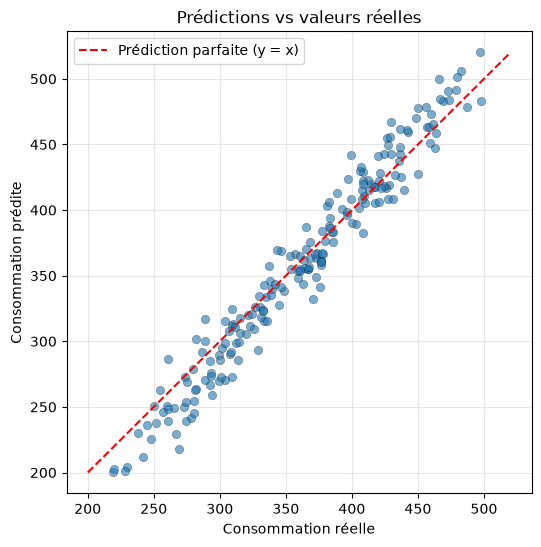

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolor="k", linewidth=0.3)

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Prédiction parfaite (y = x)")

plt.xlabel("Consommation réelle")
plt.ylabel("Consommation prédite")
plt.title("Prédictions vs valeurs réelles")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("predictions_vs_reel.png", dpi=120)
plt.show()

**Interprétation** : les points sont globalement alignés autour de la droite rouge (y = x), ce
qui montre que le modèle prédit correctement la tendance générale de la consommation. Si le modèle
était parfait, tous les points se situeraient exactement sur cette droite ; la dispersion observée
autour d'elle correspond au bruit aléatoire introduit lors de la génération des données, qui est
irréductible.

# Partie 8 — Sauvegarde du modèle

In [16]:
import os

os.makedirs("../models", exist_ok=True)
model.save("../models/modele_consommation.keras")

print("Modèle sauvegardé dans ../models/modele_consommation.keras")

Modèle sauvegardé dans ../models/modele_consommation.keras
